**RANDOM FOREST**


---

Initial implementation by - **Will Hoover**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section

In [11]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [12]:
NUM_TARGET_CLASSES = 3

In [31]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/ML Group Project CSCI 635/code')

from TreeNode import TreeNode, DecideLow, DecideMedium, DecideHigh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1HIEZWMiGzx0_4WPAaMYBLATxwVbmRyPt/ML Group Project CSCI 635/code
True


In [14]:
#############################
#  LOAD OR PREPARE DATASET  #
#############################

# Github
# X_train_path = "data/processed_data/X_train_scaled.csv"
# y_train_path = "data/processed_data/y_train.csv"
# X_test_path = "data/processed_data/X_test_scaled.csv"
# y_test_path = "data/processed_data/y_test.csv"

# Google Colab
X_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_train_scaled.csv"
y_train_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_train.csv"
X_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/X_test_scaled.csv"
y_test_path = "/content/drive/MyDrive/ML Group Project CSCI 635/data/processed_data/y_test.csv"

def load_data():
    X_train = pd.read_csv(X_train_path)
    y_train = pd.read_csv(y_train_path)
    X_test = pd.read_csv(X_test_path)
    y_test = pd.read_csv(y_test_path)

    y_train = y_train["burnout_risk"].to_numpy()
    y_test = y_test["burnout_risk"].to_numpy()
    features = X_train.columns

    return X_train, y_train, X_test, y_test, features

X_train, y_train, X_test, y_test, features = load_data()

print("Training X shape:", X_train.shape)
print("Training y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Training X shape: (1600, 11)
Training y shape: (1600,)
Test X shape: (400, 11)
Test y shape: (400,)


In [15]:
#############################
#     BOOTSTRAP SAMPLING    #
#############################

def bootstrap_sample(x, y):
    n_samples = x.shape[0]
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    return x.iloc[indices], y.iloc[indices]

In [16]:
#############################
#      ENTROPY HELPERS      #
#############################

def log2(x: float):
    if x == 0:
        return 0
    return np.log2(x)

def entropy(classes: np.ndarray):
    if len(classes) == 0:
        return 0

    prob_0 = len(classes[classes == 0]) / len(classes)
    prob_1 = len(classes[classes == 1]) / len(classes)
    prob_2 = len(classes[classes == 2]) / len(classes)

    return -(
        prob_0 * log2(prob_0) +
        prob_1 * log2(prob_1) +
        prob_2 * log2(prob_2)
    )

In [17]:
#############################
#   BEST FEATURE THRESHOLD  #
#############################

def best_avg_entropy(data: pd.DataFrame, target: np.ndarray, feature_name: str):
    feature = np.array(data[feature_name])

    avg_entropies = []
    thresh_range = np.linspace(np.min(feature), np.max(feature), num=50)

    for thresh in thresh_range:
        under_classes = target[feature <= thresh]
        over_classes = target[feature > thresh]

        avg_entropy = (
            entropy(under_classes) * (len(under_classes) / len(target)) +
            entropy(over_classes) * (len(over_classes) / len(target))
        )
        avg_entropies.append(avg_entropy)

    np_entropies = np.array(avg_entropies)
    return np.min(np_entropies), thresh_range[np.argmin(np_entropies)]

In [18]:
#############################
#   DECISION TREE BUILDER   #
#############################

def construct_node(data: pd.DataFrame, target: np.ndarray, features, parent_level: int):
    decisions = {
        0: DecideLow(parent_level + 1),
        1: DecideMedium(parent_level + 1),
        2: DecideHigh(parent_level + 1)
    }

    if parent_level == 5 or len(data) < 23:
        if len(data) == 0:
            return DecideLow(parent_level + 1)
        return decisions[np.argmax(np.bincount(target))]

    for i in range(3):
        if len(target[target == i]) / len(target) > 0.85:
            return decisions[i]

    best_entropy = 1
    best_thresh = 0
    best_att = ""

    for att in features:
        ent, thresh = best_avg_entropy(data, target, att)
        if ent < best_entropy:
            best_entropy = ent
            best_thresh = thresh
            best_att = att

    this_node = TreeNode(best_att, best_thresh, parent_level + 1)
    this_node.under = construct_node(
        data[data[best_att] <= best_thresh],
        target[data[best_att] <= best_thresh],
        features,
        parent_level + 1
    )
    this_node.over = construct_node(
        data[data[best_att] > best_thresh],
        target[data[best_att] > best_thresh],
        features,
        parent_level + 1
    )

    return this_node

In [19]:
#############################
#   RANDOM FOREST PREDICT   #
#############################

def classify(forest, x: pd.DataFrame):
    y = []

    for _, sample in x.iterrows():
        bins = [0, 0, 0]

        for tree in forest:
            bins[tree.decide(sample)] += 1

        y.append(np.argmax(bins))

    return np.array(y)

def predict_proba(forest, x: pd.DataFrame):
    probabilities = []

    for _, sample in x.iterrows():
        bins = [0, 0, 0]

        for tree in forest:
            bins[tree.decide(sample)] += 1

        probs = np.array(bins) / len(forest)
        probabilities.append(probs)

    return np.array(probabilities)

In [20]:
#############################
#    TRAIN RANDOM FOREST    #
#############################

trees = []

for _ in range(20):
    x_boot, y_boot = bootstrap_sample(X_train, pd.Series(y_train))
    trees.append(construct_node(x_boot, y_boot.to_numpy(), features, 0))

print("Number of trees in forest:", len(trees))

Number of trees in forest: 20


In [21]:
#############################
#    TRAINING EVALUATION    #
#############################

y_train_pred = classify(trees, X_train)
train_accuracy = np.mean(y_train_pred == y_train)

print("Training accuracy:", train_accuracy)

Training accuracy: 0.87875


In [22]:
#############################
#        PREDICTION         #
#############################

y_pred = classify(trees, X_test)
probabilities = predict_proba(trees, X_test)

print("Probabilities shape:", probabilities.shape)
print("Predictions shape:", y_pred.shape)

Probabilities shape: (400, 3)
Predictions shape: (400,)


In [23]:
#############################
#          ACCURACY         #
#############################

accuracy = np.mean(y_test == y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8875


In [24]:
#############################
#     PER CLASS ACCURACY    #
#############################

for i in range(NUM_TARGET_CLASSES):
    k = (y_test == i)
    acc = np.mean(y_pred[k] == i)
    print(f"Class {i} accuracy: {acc:.4f}")

Class 0 accuracy: 0.9559
Class 1 accuracy: 0.8284
Class 2 accuracy: 0.7407


In [25]:
#############################
#     CONFUSION MATRIX      #
#############################

cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
display(cm)

Predicted,0,1,2
Actual,,,
0,195,9,0
1,25,140,4
2,0,7,20


In [26]:
#############################
#  PRECISION / RECALL / F1  #
#############################

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       204
           1       0.90      0.83      0.86       169
           2       0.83      0.74      0.78        27

    accuracy                           0.89       400
   macro avg       0.87      0.84      0.86       400
weighted avg       0.89      0.89      0.89       400



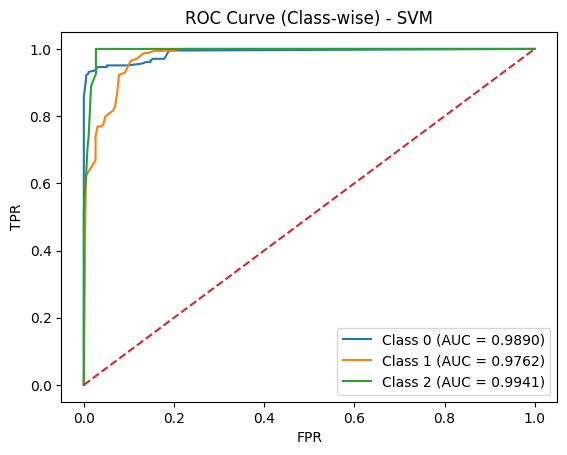

In [27]:
#############################
#  ROC CURVE (CLASS-WISE)   #
#############################

y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2])

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Class-wise) - SVM")
plt.legend()
plt.show()

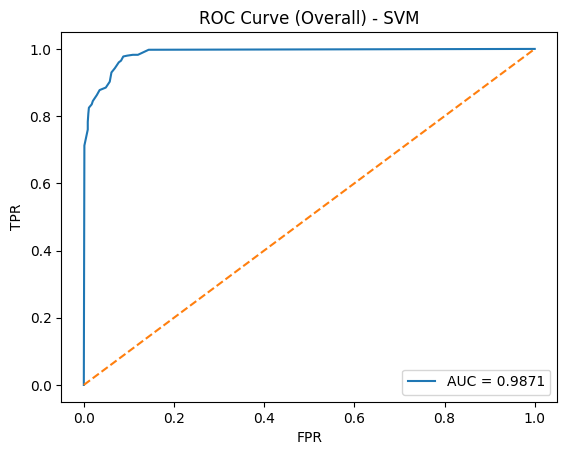

In [28]:
#############################
#    ROC CURVE (OVERALL)    #
#############################

fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), probabilities.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Overall) - SVM")
plt.legend()
plt.show()